ADVANCED IMAGE CAPTION GENERATION USING TRANSFER LEARNING, VISUAL ATTENTION AND LONG SHORT-TERM MEMORY NETWORKS

Solo Project

*   Name: Yeasmin Kabir Keya
*   ID: 0432220005101107 (8B1)



Cell 1: Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Install Libraries

In [2]:
!pip install torch torchvision nltk pillow tqdm gradio opencv-python -q

Cell 3: Import Libraries

In [3]:
import os, re, random, cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

Cell 4: Dataset Path Check

In [4]:
image_dir = "/content/drive/MyDrive/Neural Net Project/NN Project/Images"
caption_file = "/content/drive/MyDrive/Neural Net Project/NN Project/captions.txt"

print("Image folder exists:", os.path.exists(image_dir))
print("Caption file exists:", os.path.exists(caption_file))
print("Total images:", len(os.listdir(image_dir)))

Image folder exists: True
Caption file exists: True
Total images: 8093


Cell 5: Load Captions

In [5]:
df = pd.read_csv(caption_file)

print(df.head())
print("Total captions:", len(df))

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
Total captions: 40455


Cell 6: Flickr8k Dataset

In [6]:
unique_images = df["image"].unique()

df = df[df["image"].isin(unique_images)].reset_index(drop=True)

print("Selected images:", len(unique_images))
print("Selected captions:", len(df))

Selected images: 8091
Selected captions: 40455


Cell 7: Clean Captions

In [7]:
def clean_caption(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["caption"] = df["caption"].apply(clean_caption)
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...


Cell 8: Build Vocabulary

In [8]:
all_words = []

for caption in df["caption"]:
    all_words.extend(caption.split())

word_counts = Counter(all_words)

min_freq = 3

itos = ["<pad>", "<start>", "<end>", "<unk>"]

for word, count in word_counts.items():
    if count >= min_freq:
        itos.append(word)

stoi = {word: idx for idx, word in enumerate(itos)}
vocab_size = len(itos)

print("Vocabulary size:", vocab_size)

Vocabulary size: 4084


Cell 9: Encode Caption

In [9]:
def encode_caption(caption, max_len=30):
    tokens = caption.split()

    encoded = [stoi["<start>"]]

    for word in tokens:
        encoded.append(stoi.get(word, stoi["<unk>"]))

    encoded.append(stoi["<end>"])

    if len(encoded) < max_len:
        encoded += [stoi["<pad>"]] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
        encoded[-1] = stoi["<end>"]

    return encoded

Cell 10: Image Transform

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Cell 11: Dataset Class

In [11]:
class FlickrDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, max_len=30):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx]["image"]
        caption = self.df.iloc[idx]["caption"]

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        caption_encoded = torch.tensor(
            encode_caption(caption, self.max_len),
            dtype=torch.long
        )

        return image, caption_encoded

Cell 12: Train-Test Split

In [12]:
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index).reset_index(drop=True)
train_df = train_df.reset_index(drop=True)

train_dataset = FlickrDataset(train_df, image_dir, transform)
test_dataset = FlickrDataset(test_df, image_dir, transform)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 32364
Test samples: 8091


Cell 13: Device Setup

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Cell 14: Encoder CNN with Feature Maps

In [14]:
class EncoderCNN(nn.Module):
    def __init__(self, encoded_size=512):
        super(EncoderCNN, self).__init__()

        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-2]

        self.resnet = nn.Sequential(*modules)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))
        self.fc = nn.Linear(2048, encoded_size)

        for param in self.resnet.parameters():
            param.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)

        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))

        features = self.fc(features)

        return features

Cell 15: Attention Layer

In [15]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()

        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)

        att = torch.tanh(att1 + att2.unsqueeze(1))
        scores = self.full_att(att).squeeze(2)

        alpha = F.softmax(scores, dim=1)

        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)

        return context, alpha

Cell 16: Attention Decoder

In [16]:
class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=512):
        super(DecoderWithAttention, self).__init__()

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)

        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.3)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        caption_len = captions.size(1)

        embeddings = self.embedding(captions)

        h, c = self.init_hidden_state(encoder_out)

        predictions = torch.zeros(batch_size, caption_len - 1, vocab_size).to(device)
        alphas = torch.zeros(batch_size, caption_len - 1, encoder_out.size(1)).to(device)

        for t in range(caption_len - 1):
            context, alpha = self.attention(encoder_out, h)

            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)

            h, c = self.lstm_cell(lstm_input, (h, c))

            output = self.fc(self.dropout(h))

            predictions[:, t, :] = output
            alphas[:, t, :] = alpha

        return predictions, alphas

Cell 17: Initialize Model

In [17]:
encoder_dim = 512
attention_dim = 256
embed_dim = 256
decoder_dim = 512

encoder = EncoderCNN(encoded_size=encoder_dim).to(device)

decoder = DecoderWithAttention(
    attention_dim=attention_dim,
    embed_dim=embed_dim,
    decoder_dim=decoder_dim,
    vocab_size=vocab_size,
    encoder_dim=encoder_dim
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=stoi["<pad>"])
optimizer = torch.optim.Adam(decoder.parameters(), lr=0.0005)

print("Attention model ready")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s]


Attention model ready


Cell 18: Training Loop with Backup

In [31]:
num_epochs = 8
train_losses = []

backup_path = "/content/drive/MyDrive/Neural Net Project/NN Project/attention_backup_latest.pth"

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()

    total_loss = 0

    for images, captions in tqdm(train_loader):
        images = images.to(device)
        captions = captions.to(device)

        with torch.no_grad():
            encoder_out = encoder(images)

        outputs, alphas = decoder(encoder_out, captions)

        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(-1, vocab_size),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    torch.save({
        "encoder": encoder.state_dict(),
        "decoder": decoder.state_dict(),
        "stoi": stoi,
        "itos": itos,
        "train_losses": train_losses
    }, backup_path)

    print("Backup saved")

100%|██████████| 506/506 [05:13<00:00,  1.61it/s]


Epoch [1/8], Loss: 2.0384
Backup saved


100%|██████████| 506/506 [05:04<00:00,  1.66it/s]


Epoch [2/8], Loss: 1.9553
Backup saved


100%|██████████| 506/506 [05:02<00:00,  1.67it/s]


...

Epoch [6/8], Loss: 1.6762
Backup saved


100%|██████████| 506/506 [05:04<00:00,  1.66it/s]


Epoch [7/8], Loss: 1.6177
Backup saved


100%|██████████| 506/506 [05:32<00:00,  1.52it/s]


Epoch [8/8], Loss: 1.5582
Backup saved


Cell 19: Save Final Model

In [32]:
save_path = "/content/drive/MyDrive/Neural Net Project/NN Project/final_attention_caption_model.pth"

torch.save({
    "encoder": encoder.state_dict(),
    "decoder": decoder.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "train_losses": train_losses
}, save_path)

print("Final Attention Model Saved Successfully")

Final Attention Model Saved Successfully


Cell 20: Loss Graph

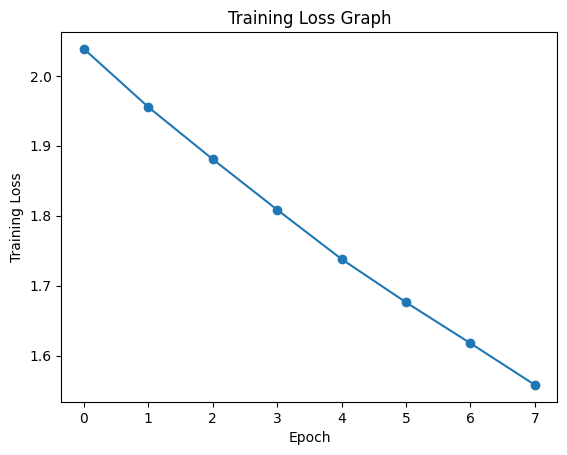

In [33]:
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Graph")
plt.show()

Cell 21: Caption Generation with Attention

In [34]:
def generate_caption_attention(image_path, max_len=30):
    encoder.eval()
    decoder.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    result = []
    attention_maps = []

    with torch.no_grad():
        encoder_out = encoder(image_tensor)

        h, c = decoder.init_hidden_state(encoder_out)

        word = torch.tensor([stoi["<start>"]]).to(device)

        for _ in range(max_len):
            embedding = decoder.embedding(word)

            context, alpha = decoder.attention(encoder_out, h)

            lstm_input = torch.cat([embedding, context], dim=1)

            h, c = decoder.lstm_cell(lstm_input, (h, c))

            output = decoder.fc(h)

            predicted = output.argmax(1)
            predicted_word = itos[predicted.item()]

            if predicted_word == "<end>":
                break

            if predicted_word not in ["<start>", "<pad>"]:
                result.append(predicted_word)
                attention_maps.append(alpha.cpu().numpy().reshape(7, 7))

            word = predicted

    return " ".join(result), attention_maps

Cell 22: Test One Image

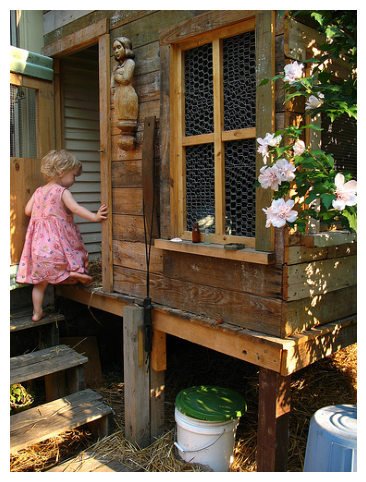

Generated Caption:
a little girl in a pink dress is standing on a wooden bench

Actual Caption:
a little girl climbing into a wooden playhouse


In [35]:
idx = 0

sample_image = os.path.join(image_dir, test_df.iloc[idx]["image"])

img = Image.open(sample_image)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

caption, attention_maps = generate_caption_attention(sample_image)

print("Generated Caption:")
print(caption)

print("\nActual Caption:")
print(test_df.iloc[idx]["caption"])

Cell 23: Show Attention Heatmap

In [36]:
def show_attention_on_image(image_path, attention_map):
    image = Image.open(image_path).convert("RGB").resize((224,224))
    img_np = np.array(image)

    heatmap = cv2.resize(attention_map, (224,224))
    heatmap = heatmap / np.max(heatmap)
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Attention Heatmap")
    plt.axis("off")

    plt.show()

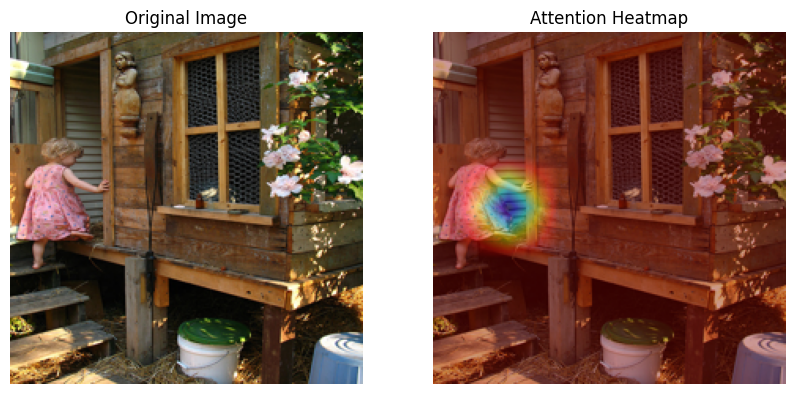

In [37]:
if len(attention_maps) > 0:
    show_attention_on_image(sample_image, attention_maps[0])

Cell 24: Test Multiple Images

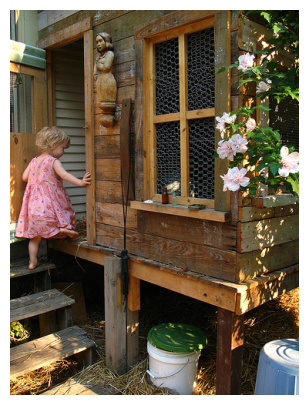

Generated: a little girl in a pink dress is standing on a wooden bench
Actual: a little girl climbing into a wooden playhouse


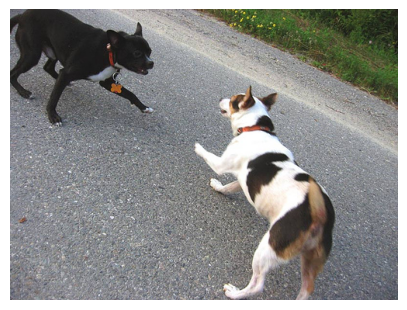

Generated: a black dog and a white dog are running in the street
Actual: two dogs on pavement moving toward each other


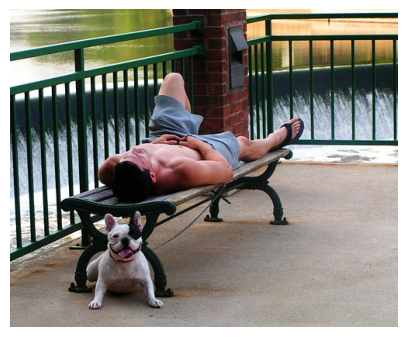

Generated: a man laying on a bench with a dog on a leash
Actual: a man lays on the bench to which a white dog is also tied


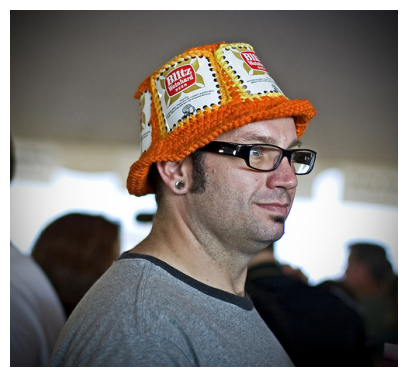

Generated: a man with a hat wears a hat
Actual: a man wears an orange hat and glasses


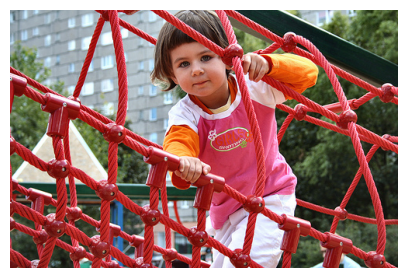

Generated: a young boy climbing a rope
Actual: a small child grips onto the red ropes at the playground


In [38]:
for i in range(5):
    sample_image = os.path.join(image_dir, test_df.iloc[i]["image"])

    img = Image.open(sample_image)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    caption, _ = generate_caption_attention(sample_image)

    print("Generated:", caption)
    print("Actual:", test_df.iloc[i]["caption"])
    print("=" * 80)

Cell 25: BLEU Score

In [39]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

bleu1_scores = []
bleu2_scores = []

for i in range(100):
    image_path = os.path.join(image_dir, test_df.iloc[i]["image"])

    actual = test_df.iloc[i]["caption"].split()
    generated, _ = generate_caption_attention(image_path)
    generated = generated.split()

    if len(generated) > 0:
        bleu1 = sentence_bleu([actual], generated, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu([actual], generated, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)

        bleu1_scores.append(bleu1)
        bleu2_scores.append(bleu2)

print("Average BLEU-1:", round(sum(bleu1_scores)/len(bleu1_scores), 4))
print("Average BLEU-2:", round(sum(bleu2_scores)/len(bleu2_scores), 4))

Average BLEU-1: 0.3411
Average BLEU-2: 0.187


Cell 26: Gradio Demo

In [40]:
import gradio as gr

def caption_app(image):
    temp_path = "/content/temp_image.jpg"
    image.save(temp_path)

    caption, _ = generate_caption_attention(temp_path)

    return caption

demo = gr.Interface(
    fn=caption_app,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Textbox(label="Generated Caption"),
    title="Image Caption Generator using CNN-LSTM with Attention",
    description="This project uses ResNet50, LSTM, Attention Mechanism, BLEU Evaluation, and Gradio Interface."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e463f8efdb0e91d438.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
